<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/FeatureEng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTANT :


In [1]:
# path = '/content/drive/MyDrive/Thesis_Data/'
path = '../Thesis_Data/'




## 🐄 Feature Engineering & Data Cleaning Pipeline

This section outlines the transformation, calculation, and filtering steps required to prepare the raw dataset for modeling.

### 1. Data Transformation (Scaling)
Standardize the primary yield components to their proper decimal scales:
*   **Milk Yield:** `milk_kg` = $\frac{milk\_kg}{10}$
*   **Fat Percentage:** `fat_p` = $\frac{fat\_p}{100}$
*   **Protein Percentage:** `protein_p` = $\frac{protein\_p}{100}$

---

### 2. Feature Engineering (New Variables)
We derive biological and performance indicators using the following formulas:

| Variable | Description | Formula |
| :--- | :--- | :--- |
| **AFC** | Age at First Calving | $DTC - DTB$ |
| **DIM** | Days In Milk | $DTT - DTC$ |
| **ECM** | Energy Corrected Milk | $[((Fat \times 10) - 40) + ((Protein \times 10) - 31)] \times 0.01155 + 1) \times milk$ |
| **SCS** | Somatic Cell Score | $\log_2(\frac{cells}{100}) + 3$ |

---

### 3. Primary Data Filters
To ensure biological plausibility and data quality, records must satisfy the following constraints:

*   **Production Limits:**
    *   $0.4 \leq \text{Milk} \leq 26.5$
    *   $1.6 \leq \text{Fat} \leq 15.05$
    *   $2.67 \leq \text{Protein} \leq 6.68$
    *   $-2.06 \leq \text{SCS} \leq 10.73$
*   **Zero-Value Guard:** $ECM \leq 30$ AND ($\text{Protein, Fat, Milk} \neq 0$)
*   **Lifecycle & Parity:**
    *   $720 \leq \text{AFC} \leq 1440$
    *   $0 < \text{DIM} \leq 365$
    *   $NM = 2$ (Specific Parity/Management group)

---

### 4. Weather & Environmental Features
For each weather metric (**Temperature, Humidity, Wind, THI1, THI2, WHI**), we calculate a rolling window of descriptive statistics and lagged variables:

*   **Aggregates:** Average, Maximum, and Minimum.
*   **Temporal Lags:** 1-day, 2-day, and 3-day lags (e.g., `avg-lag1`).
*   **Composite Index:** **THI Compose** calculated using a **5-day rolling window** to capture cumulative heat stress.

---

### 5. Final Quality Assurance (Outlier Removal)
The final step removes low-density data points to ensure statistical significance:
1.  **Farm Level:** Remove any farms with **< 5 records** per day.
2.  **Animal Level:** Remove any individual animals with **< 3 total test records**.

## Load Animal Data


Load the dataset from **path** + 'Dati_ok.txt' into a pandas DataFrame.


In [2]:
datasetAnimalPath = path + 'Dati_ok.txt'

In [3]:
import pandas as pd

col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

with open(datasetAnimalPath, 'r') as file:
    next(file)

    for line in file:
        line = line.strip()

        if not line:
            continue

        parts = line.split(',')

        if len(parts) == 11:
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            parts.pop(2)
            cleaned_rows.append(parts)

df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

print(df_animal.head(5))
print(f"\nTotal rows loaded: {len(df_animal)}")

   Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0     521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1     521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2     521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3     521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4     521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   

   milk_kg  fat_p  protein_p  cells  NM  
0      141    617        484    656   2  
1      168    682        417    827   2  
2      134    763        459   1144   2  
3      108    663        454   1403   2  
4       94    688        451   1805   2  

Total rows loaded: 2593267



## 1. Data Transformation (Scaling)
Standardize the primary yield components to their proper decimal scales:
*   **Milk Yield:** `milk_kg` = $\frac{milk\_kg}{10}$
*   **Fat Percentage:** `fat_p` = $\frac{fat\_p}{100}$
*   **Protein Percentage:** `protein_p` = $\frac{protein\_p}{100}$


In [14]:
df_animal['milk_kg'] = df_animal['milk_kg'] /10
df_animal['fat_p'] = df_animal['fat_p'] / 100
df_animal['protein_p'] = df_animal['protein_p'] / 100
# df_animal['cells'] = df_animal['cells'] * 100000

## 2. Feature Engineering (New Variables)
We derive biological and performance indicators using the following formulas:

| Variable | Description | Formula |
| :--- | :--- | :--- |
| **AFC** | Age at First Calving | $DTC - DTB$ |
| **DIM** | Days In Milk | $DTT - DTC$ |
| **ECM** | Energy Corrected Milk | $[((Fat \times 10) - 40) + ((Protein \times 10) - 31)] \times 0.01155 + 1) \times milk$ |
| **SCS** | Somatic Cell Score | $\log_2(\frac{cells}{100}) + 3$ |


In [14]:
df_animal[df_animal['cells']==0] = 1

/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_98189/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_animal[df_animal['cells']==0] = 1
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_98189/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_animal[df_animal['cells']==0] = 1
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_98189/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype

In [15]:
import numpy as np
df_animal['ECM'] = (((((df_animal['fat_p'] * 10) - 40) + ((df_animal['protein_p'] * 10) - 31)) * 0.01155) + 1) * df_animal['milk_kg']
df_animal['SCS'] = np.log2((df_animal['cells']) / 100) + 3
df_animal['AFC'] = df_animal['dtc'] - df_animal['dtb']
df_animal['DIM'] = df_animal['dtt'] - df_animal['dtc']
df_animal['DIM'] = pd.to_timedelta(df_animal['DIM']).dt.days


## 3. Primary Data Filters
To ensure biological plausibility and data quality, records must satisfy the following constraints:

#### 1. Component Thresholds
$$
\text{milk} =
\begin{cases}
\text{remove} & \text{if } \text{milk} \le 0.40 \text{ or } \text{milk} \ge 26.50 \\
\text{milk} & \text{otherwise}
\end{cases}
$$

$$
\text{fat} =
\begin{cases}
\text{remove} & \text{if } \text{fat} \le 1.60 \text{ or } \text{fat} \ge 15.05 \\
\text{fat} & \text{otherwise}
\end{cases}
$$

$$
\text{protein} =
\begin{cases}
\text{remove} & \text{if } \text{protein} \le 2.67 \text{ or } \text{protein} \ge 6.68 \\
\text{protein} & \text{otherwise}
\end{cases}
$$

$$
\text{SCS} =
\begin{cases}
\text{remove} & \text{if } \text{SCS} \le -2.06 \text{ or } \text{SCS} \ge 10.73 \\
\text{SCS} & \text{otherwise}
\end{cases}
$$

#### 2. ECM Logic
$$
\text{ECM} =
\begin{cases}
\text{remove} & \text{if } (\text{milk}, \text{fat}, \text{or protein}) = 0 \\
\text{remove} & \text{if } \text{ECM} \ge 30 \\
\text{ECM} & \text{otherwise}
\end{cases}
$$

#### 3. Inclusion Criteria (Days)
$$720 \le \text{AFC} \le 1440$$
$$0 < \text{DIM} \leq 365$$
$$1 < \text{NM} < 3$$


In [16]:
initial_count = len(df_animal)

def print_loss(current_df, step_name):
    removed = initial_count - len(current_df)
    percent = (removed / initial_count) * 100
    print(f"Total rows removed after {step_name} filtering: {removed} ({percent:.2f}% of total data lost)")


df_animal_filtered = df_animal[(df_animal['milk_kg'] >= 0.4) & (df_animal['milk_kg'] <= 26.5)]
print_loss(df_animal_filtered, "milk")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['fat_p'] >= 1.6) & (df_animal_filtered['fat_p'] <= 15.05)]
print_loss(df_animal_filtered, "fat_p")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['protein_p'] >= 2.67) & (df_animal_filtered['protein_p'] <= 6.68)]
print_loss(df_animal_filtered, "protein_p")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['SCS'] >= -2.06) & (df_animal_filtered['SCS'] <= 10.73)]
print_loss(df_animal_filtered, "SCS")
df_animal_filtered = df_animal_filtered[df_animal_filtered['ECM'] <= 301]
print_loss(df_animal_filtered, "ECM")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['AFC'] >= pd.Timedelta(days=720)) & (df_animal_filtered['AFC'] <= pd.Timedelta(days=1440))]
print_loss(df_animal_filtered, "AFC")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['DIM'] > 0) & (df_animal_filtered['DIM'] <= 365)]
print_loss(df_animal_filtered, "DIM")
df_animal_filtered = df_animal_filtered[df_animal_filtered['NM'] == 2]
print_loss(df_animal_filtered, "NM")


Total rows removed after milk filtering: 1610 (0.06% of total data lost)
Total rows removed after fat_p filtering: 151175 (5.83% of total data lost)
Total rows removed after protein_p filtering: 153274 (5.91% of total data lost)
Total rows removed after SCS filtering: 155151 (5.98% of total data lost)
Total rows removed after ECM filtering: 155151 (5.98% of total data lost)
Total rows removed after AFC filtering: 1866833 (71.99% of total data lost)
Total rows removed after DIM filtering: 1887930 (72.80% of total data lost)
Total rows removed after NM filtering: 1901584 (73.33% of total data lost)


### adding milk and protein lag 

In [ ]:
# Lagged target values — these will transform your predictions
df_animal_filtered = df_animal_filtered.sort_values(['Farm_Code', 'Animal_ID', 'dtt'])

df_animal_filtered['milk_kg_lag1']   = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(1)
df_animal_filtered['milk_kg_lag2']   = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(2)

df_animal_filtered['protein_p_lag1'] = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(1)
df_animal_filtered['protein_p_lag2'] = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(2)

## 4. Final Quality Assurance (Outlier Removal)
The final step removes low-density data points to ensure statistical significance:
1.  **Farm Level:** Remove any farms with **< 5 records** per day.
2.  **Animal Level:** Remove any individual animals with **< 3 total test records**.

In [17]:
df_animal_filtered['dtt'] = pd.to_datetime(df_animal_filtered['dtt'])

print("=== BEFORE ===")
print(f"Records:   {len(df_animal_filtered):,}")
print(f"Animals:   {df_animal_filtered['Animal_ID'].nunique():,}")
print(f"Farms:     {df_animal_filtered['Farm_Code'].nunique():,}")
lactations_before = df_animal_filtered.groupby('Animal_ID').ngroups
print(f"Lactations:{lactations_before:,}")

# Step 1 — Filter 2: farm-day density
daily_counts = df_animal_filtered.groupby(['Farm_Code', 'dtt'])['Animal_ID'].nunique()
valid_days = daily_counts[daily_counts >= 5]
df = df_animal_filtered.merge(valid_days.rename('day_count').reset_index(), on=['Farm_Code', 'dtt'])
df = df.drop(columns='day_count')

# Step 2 — Filter 1: lactation length
lac_counts = df.groupby(['Farm_Code', 'Animal_ID']).size()
valid_lacs = lac_counts[lac_counts >= 3].reset_index()[['Farm_Code', 'Animal_ID']]
df = df.merge(valid_lacs, on=['Farm_Code', 'Animal_ID'])

print("\n=== AFTER ===")
print(f"Records:   {len(df):,}")
print(f"Animals:   {df['Animal_ID'].nunique():,}")
print(f"Farms:     {df['Farm_Code'].nunique():,}")
lactations_after = df.groupby('Animal_ID').ngroups
print(f"Lactations:{lactations_after:,}")



=== BEFORE ===
Records:   691,683
Animals:   88,577
Farms:     326
Lactations:88,577

=== AFTER ===
Records:   671,655
Animals:   81,119
Farms:     314
Lactations:81,119


## Saving Data To csv

In [18]:
df.to_csv(path+'Final_Data/After_Processing.csv',index=False)

### Parameters Analysis after outlier removal

In [4]:
df_animal_filtered = pd.read_csv(path+'Final_Data/After_Processing.csv')

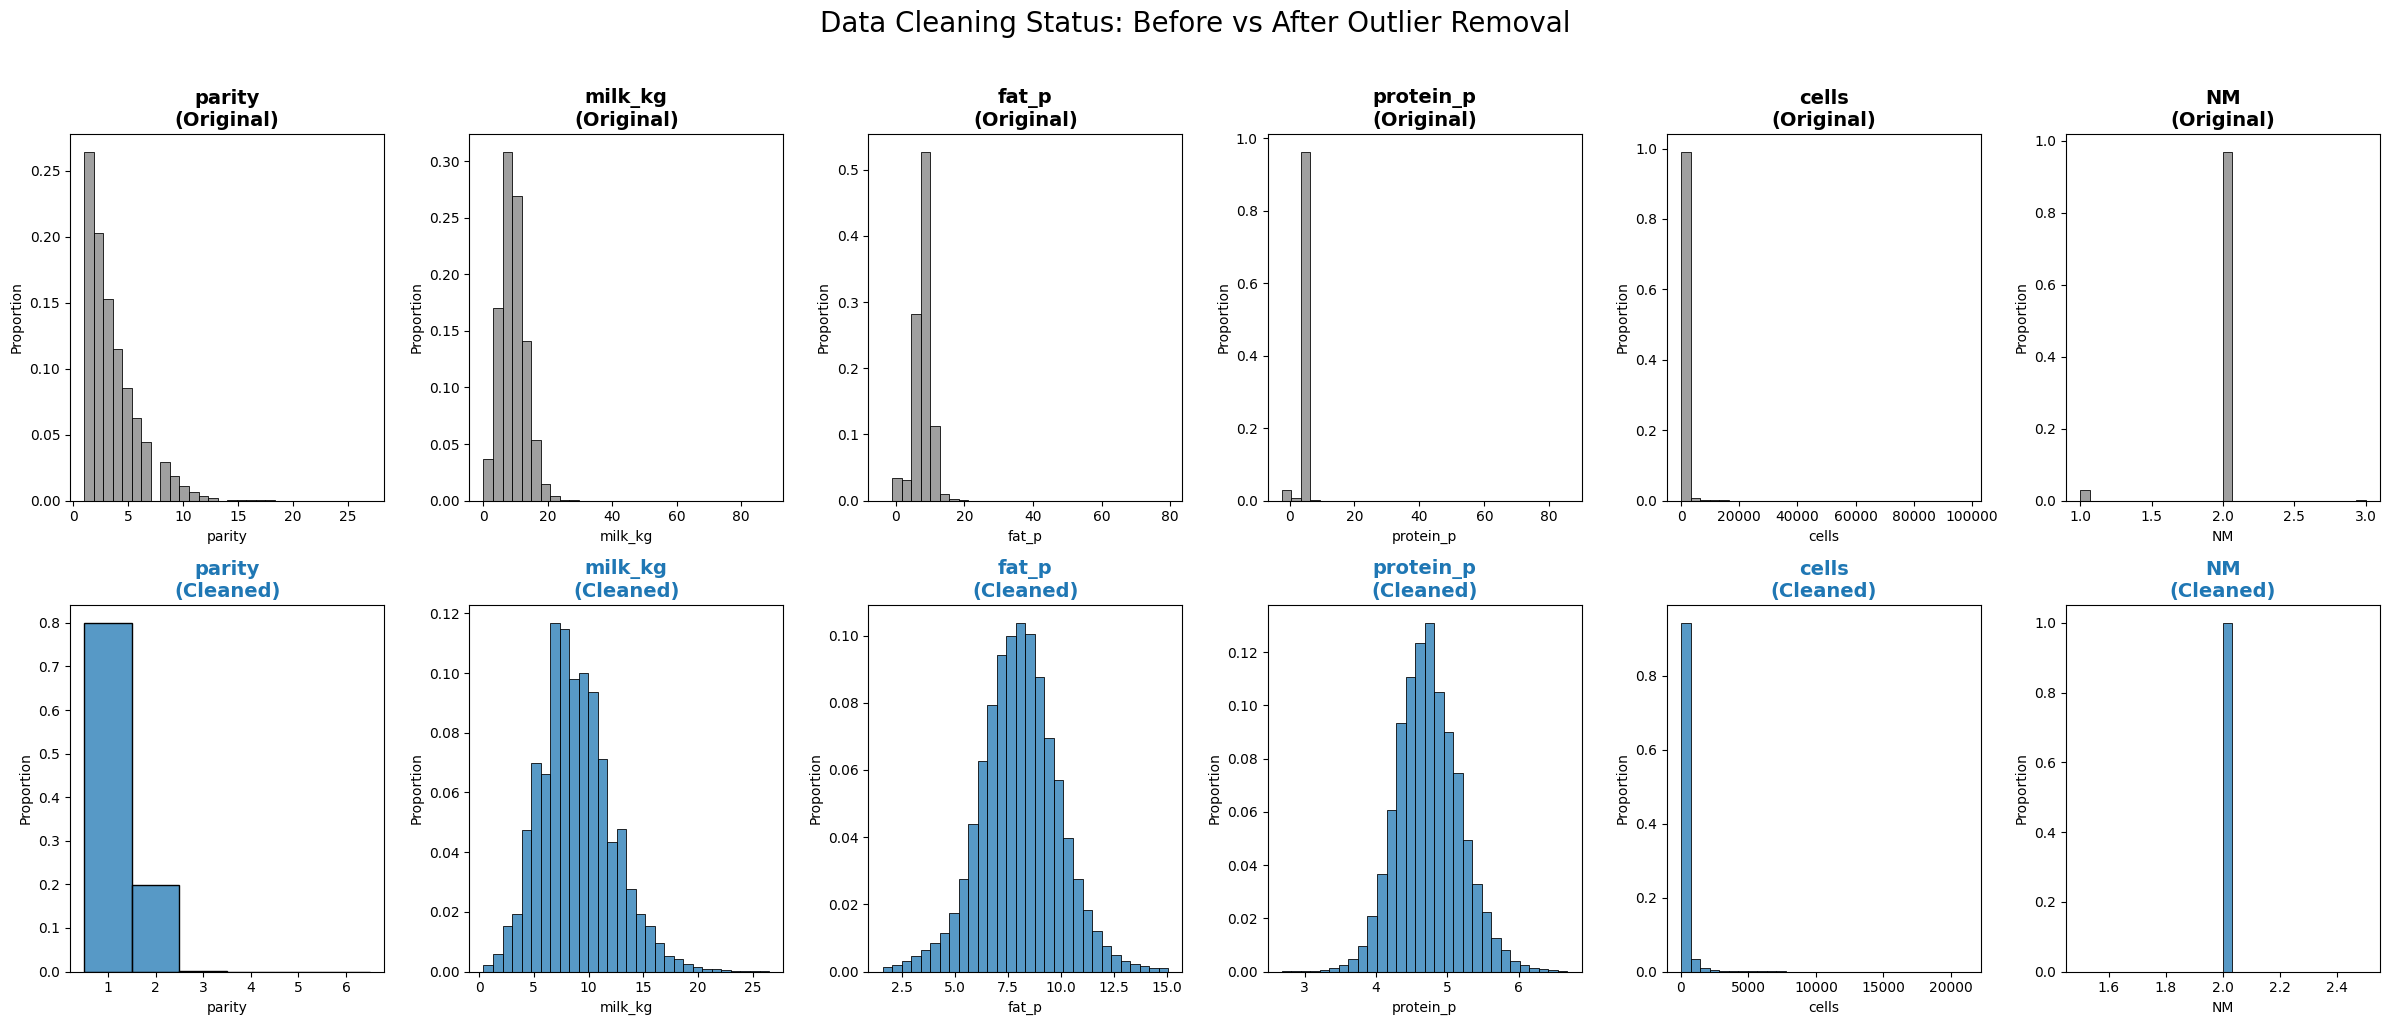

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create 2 rows (Top: Before, Bottom: After)
fig, axes = plt.subplots(nrows=2, ncols=len(numerical_cols), figsize=(24, 10))

for i, col in enumerate(numerical_cols):
    # --- TOP ROW: BEFORE (Original Data) ---
    sns.histplot(df_animal[col], ax=axes[0, i], kde=False, 
                 color="grey", bins=30, stat="proportion")
    axes[0, i].set_title(f'{col}\n(Original)', fontsize=14, fontweight='bold')
    axes[0, i].set_ylabel('Proportion')
    
    # --- BOTTOM ROW: AFTER (Cleaned Data) ---
    # Use discrete=True for 'parity' to fix the decimal/comb issue
    is_discrete = True if col == 'parity' else False
    
    sns.histplot(df_animal_filtered[col], ax=axes[1, i], kde=False, 
                 color="#1f77b4", bins=30, stat="proportion", discrete=is_discrete)
    axes[1, i].set_title(f'{col}\n(Cleaned)', fontsize=14, fontweight='bold', color="#1f77b4")
    axes[1, i].set_ylabel('Proportion')

# Add a main title to the whole figure
plt.suptitle('Data Cleaning Status: Before vs After Outlier Removal', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_9646/2624213690.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x='status', y=col, ax=axes[i], palette="muted")
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_9646/2624213690.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x='status', y=col, ax=axes[i], palette="muted")
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_9646/2624213690.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x='s

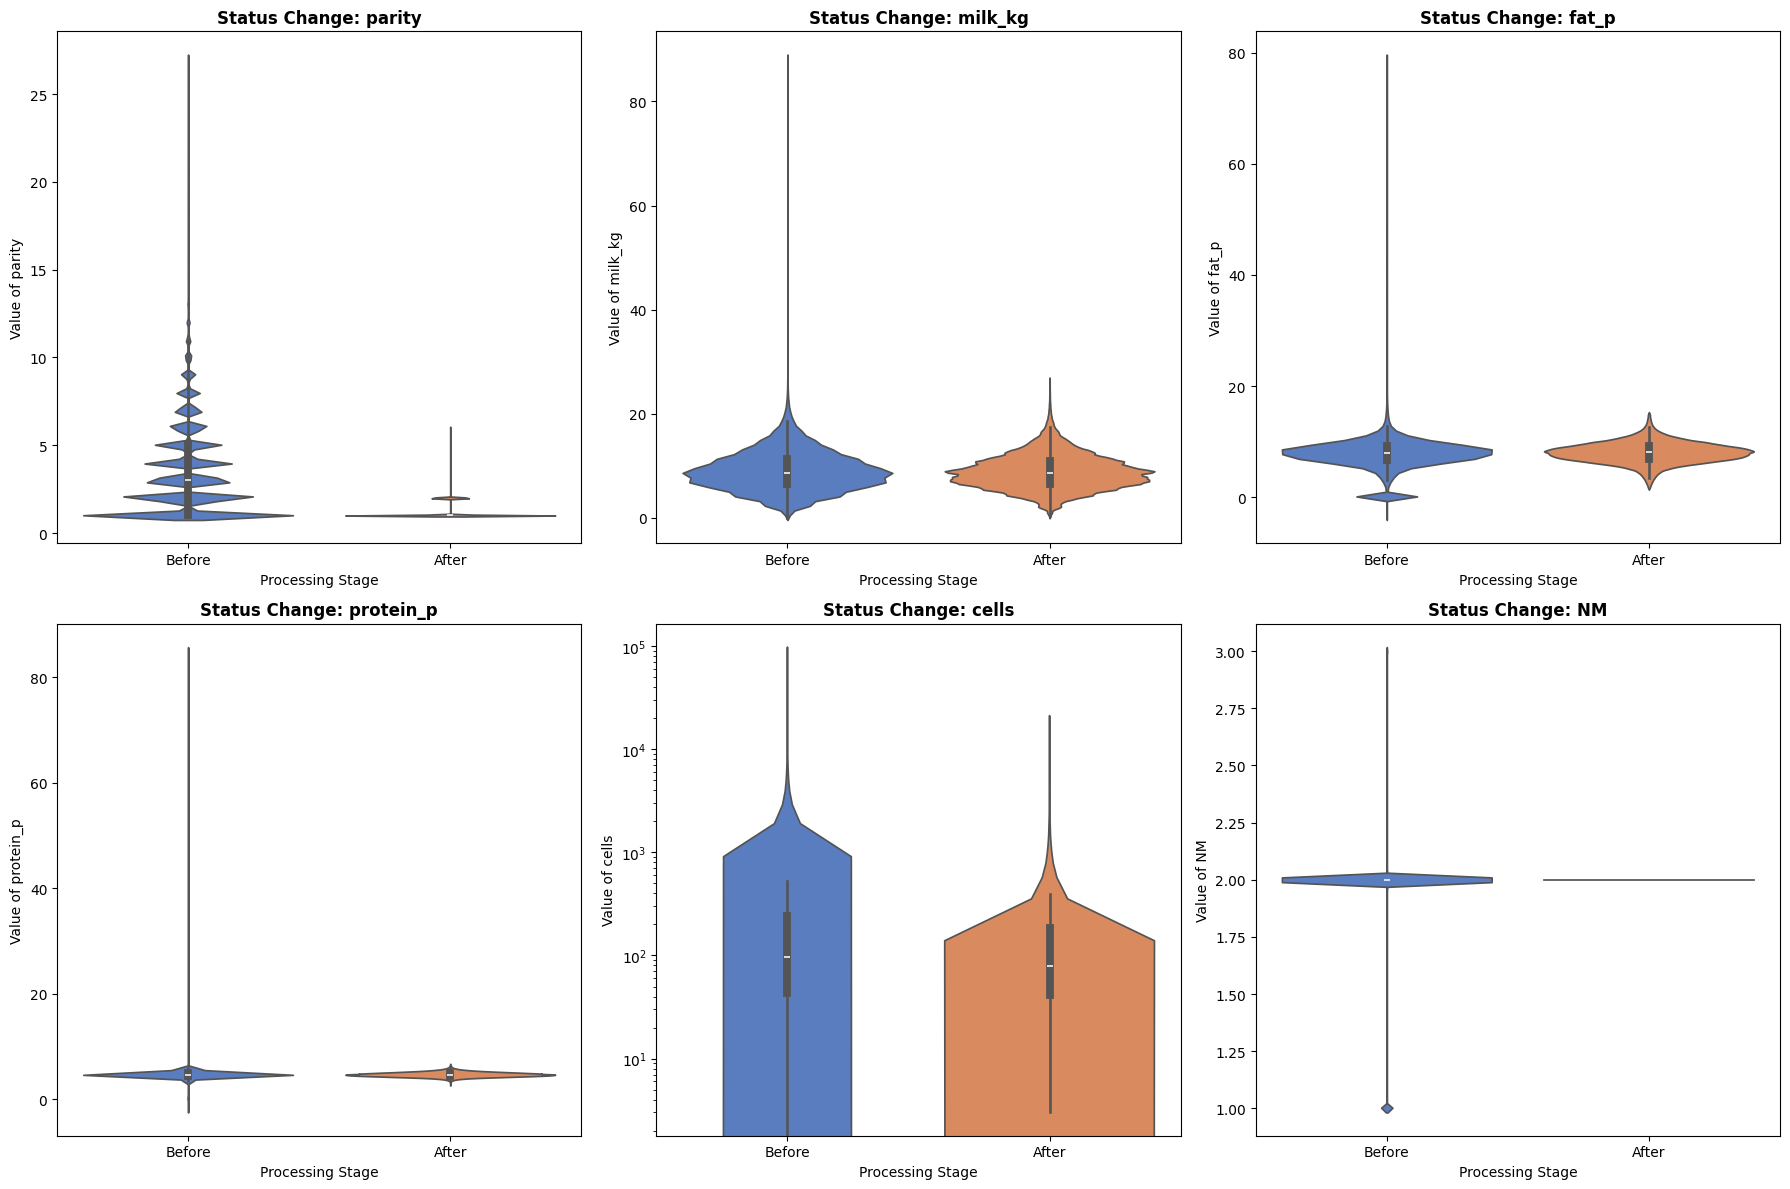

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine your data for plotting
df_animal['status'] = 'Before'
df_animal_filtered['status'] = 'After'
combined_df = pd.concat([df_animal, df_animal_filtered])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Use 'split=True' to put Before and After in the same 'violin'
    sns.violinplot(data=combined_df, x='status', y=col, ax=axes[i], palette="muted")
    
    axes[i].set_title(f'Status Change: {col}', fontweight='bold')
    axes[i].set_xlabel('Processing Stage')
    axes[i].set_ylabel(f'Value of {col}')

    # Optional: Log scale for 'cells' if it's still too squashed
    if col == 'cells':
        axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
df.

## Merginf all the data together

In [19]:
import pandas as pd
import os
from pathlib import Path
from datetime import datetime

def merge_animal_weather_data(animal_file, weather_folder, output_file):

    print("="*80)
    print("MERGING ANIMAL DATA WITH WEATHER DATA")
    print("="*80)

    # 1. Read the animal data
    print(f"\n1. Reading animal data from: {animal_file}")
    animal_df = pd.read_csv(animal_file)
    print(f"   ✓ Loaded {len(animal_df):,} animal records")
    
    print(f"\n2. Converting 'dtt' column to date format...")
    animal_df['dtt_date'] = pd.to_datetime(animal_df['dtt'], format='mixed', errors='coerce').dt.date

    null_dates = animal_df['dtt_date'].isnull().sum()
    if null_dates > 0:
        print(f"   ⚠ Warning: {null_dates:,} records have invalid dates and will be skipped")

    unique_farms = animal_df['Farm_Code'].unique()
    print(f"   ✓ Found {len(unique_farms)} unique farms in animal data")

    # 2. Load and Transform weather data
    print(f"\n3. Loading and processing weather data files from: {weather_folder}")
    weather_files = list(Path(weather_folder).glob("farm_*_with_indices.csv"))

    if not weather_files:
        print(f"   ✗ ERROR: No weather files found in {weather_folder}")
        return

    # We will store all processed weather DataFrames in a list and concatenate them later
    all_weather_dfs = []

    for weather_file in weather_files:
        try:
            filename = weather_file.stem
            parts = filename.split('_')

            farm_code = None
            for part in parts[1:]:
                clean_part = part.replace('.0', '').replace('.', '')
                if clean_part.isdigit():
                    farm_code = int(clean_part)
                    break

            if farm_code is None:
                continue

            weather_df = pd.read_csv(weather_file)
            weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date
            
            # SORT BY DATE is crucial for accurate shifts and rolling windows
            weather_df = weather_df.sort_values('date').reset_index(drop=True)
            weather_df['Farm_Code'] = farm_code 

            # 1. Temporal Lags (1, 2, 3 days) ONLY for average columns
            # Dynamically grab all columns ending in '_avg'
            avg_columns = [col for col in weather_df.columns if col.endswith('_avg')]
            
            for col in avg_columns:
                weather_df[f'{col}_lag1'] = weather_df[col].shift(1)
                weather_df[f'{col}_lag2'] = weather_df[col].shift(2)
                weather_df[f'{col}_lag3'] = weather_df[col].shift(3).bfill()

            # 2. Composite Index (5-day centered window) for THI averages
            # Look specifically for THI columns in the averages list
            thi_avg_cols = [col for col in avg_columns if 'THI' in col]
            
            for thi_col in thi_avg_cols:
                # Creates column names like 'THI_1_Compose' by stripping out '_avg'
                base_name = thi_col.replace('_avg', '') 
                
                # center=True ensures the window uses (n-2, n-1, n, n+1, n+2)
                weather_df[f'{base_name}_Compose'] = weather_df[thi_col].rolling(window=5, center=True, min_periods=1).mean()

            all_weather_dfs.append(weather_df)
            print(f"   ✓ Processed farm {farm_code}: {len(weather_df)} records")

        except Exception as e:
            print(f"   ✗ Error loading/processing {weather_file.name}: {str(e)}")
            continue

    # Combine all farm weather data into one massive DataFrame
    full_weather_df = pd.concat(all_weather_dfs, ignore_index=True)
    
    farms_with_weather = set(full_weather_df['Farm_Code'].unique())
    farms_in_animal = set(unique_farms)
    farms_missing_weather = farms_in_animal - farms_with_weather

    if farms_missing_weather:
        print(f"\n   ⚠ WARNING: {len(farms_missing_weather)} farms in animal data don't have weather files.")

    # 3. Merge data (Optimized Vectorized Merge)
    print(f"\n4. Merging animal data with weather data (Vectorized)...")
    initial_len = len(animal_df)
    
    # Left Join: keeps all animal records, attaches weather where Farm_Code AND Date match
    merged_df = pd.merge(
        animal_df, 
        full_weather_df, 
        left_on=['Farm_Code', 'dtt_date'], 
        right_on=['Farm_Code', 'date'], 
        how='left'
    )

    # Calculate statistics based on missing 'date' (meaning the join failed for that row)
    matched_records = merged_df['date'].notna().sum()
    no_weather = initial_len - matched_records

    # Clean up redundant columns from the merge
    merged_df = merged_df.drop(['dtt_date', 'date'], axis=1)

    print(f"\n5. Merge Statistics:")
    print(f"   ✓ Successfully matched: {matched_records:,} / {initial_len:,} records ({matched_records/initial_len*100:.1f}%)")
    print(f"   ⚠ Could not match weather/date: {no_weather:,} records")

    # 4. Save merged data
    print(f"\n6. Saving merged data to: {output_file}")
    merged_df.to_csv(output_file, index=False)
    print(f"   ✓ Saved {len(merged_df):,} records")
    print(f"   ✓ Total columns: {len(merged_df.columns)}")

    print("\n" + "="*80)
    print("✓ PROCESS COMPLETE!")
    print("="*80)

    return merged_df

# Set your paths here

animal_file =  path + "Final_Data/After_Processing.csv"
weather_folder = path + "farm_weather_indices"
output_file = path + "Final_Data/Final_Merged_Data.csv"

# Run the merge
merged_data = merge_animal_weather_data(animal_file, weather_folder, output_file)

MERGING ANIMAL DATA WITH WEATHER DATA

1. Reading animal data from: ../Thesis_Data/Final_Data/After_Processing.csv
   ✓ Loaded 671,655 animal records

2. Converting 'dtt' column to date format...
   ✓ Found 314 unique farms in animal data

3. Loading and processing weather data files from: ../Thesis_Data/farm_weather_indices
   ✓ Processed farm 5970082: 4749 records
   ✓ Processed farm 7390481: 4749 records
   ✓ Processed farm 1126225: 4749 records
   ✓ Processed farm 7014059: 4749 records
   ✓ Processed farm 7610622: 4749 records
   ✓ Processed farm 6811565: 4749 records
   ✓ Processed farm 7030383: 4749 records
   ✓ Processed farm 5700612: 4749 records
   ✓ Processed farm 6811496: 4749 records
   ✓ Processed farm 5700749: 4749 records
   ✓ Processed farm 5010267: 4749 records
   ✓ Processed farm 6800432: 4749 records
   ✓ Processed farm 5600187: 4749 records
   ✓ Processed farm 5700744: 4749 records
   ✓ Processed farm 6800007: 4749 records
   ✓ Processed farm 7030393: 4749 records
 